In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
# Parámetros iniciales
S0 = 70.0      
K = 72.0       
T = 0.25       
r = 0.11       
sigma = 0.20   
B = 85.0       
simulaciones = 50000
pasos = 90     

dt = T / pasos
df = np.exp(-r * T) # Factor de descuento

#  SIMULACIÓN DE TRAYECTORIAS 
# Creamos una matriz donde cada fila es una trayectoria
np.random.seed(42) # Para resultados reproducibles
Z = np.random.standard_normal((simulaciones, pasos))
retornos_diarios = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

# Matriz de precios (comienza en S0)
precios = np.zeros((simulaciones, pasos + 1))
precios[:, 0] = S0

for t in range(1, pasos + 1):
    precios[:, t] = precios[:, t-1] * retornos_diarios[:, t-1]

# calcu8lo de pagos 
ST = precios[:, -1] 

# Call Europea
payoff_call = np.maximum(ST - K, 0)

# Put Europea
payoff_put = np.maximum(K - ST, 0)

# Call Asiática 
promedio_trayectoria = np.mean(precios, axis=1)
payoff_asiatica = np.maximum(promedio_trayectoria - K, 0)

# Call Up-and-Out
# Si en algún momento de la trayectoria el precio toca o supera B, el payoff es 0
toco_barrera = np.any(precios >= B, axis=1)
payoff_barrera = np.where(toco_barrera, 0, payoff_call)

#  VALUACIÓN (Promedio de Payoffs descontados)
precio_call = df * np.mean(payoff_call)
precio_put = df * np.mean(payoff_put)
precio_asiatica = df * np.mean(payoff_asiatica)
precio_barrera = df * np.mean(payoff_barrera)

# RESULTADOS 
data = {
    "Tipo de Opción": ["Call Europea", "Put Europea", "Call Asiática", "Call Up-and-Out"],
    "Precio Valuado": [precio_call, precio_put, precio_asiatica, precio_barrera]
}
tabla_comparativa = pd.DataFrame(data)
print(tabla_comparativa)



    Tipo de Opción  Precio Valuado
0     Call Europea        2.750821
1      Put Europea        2.812765
2    Call Asiática        1.146711
3  Call Up-and-Out        1.802681


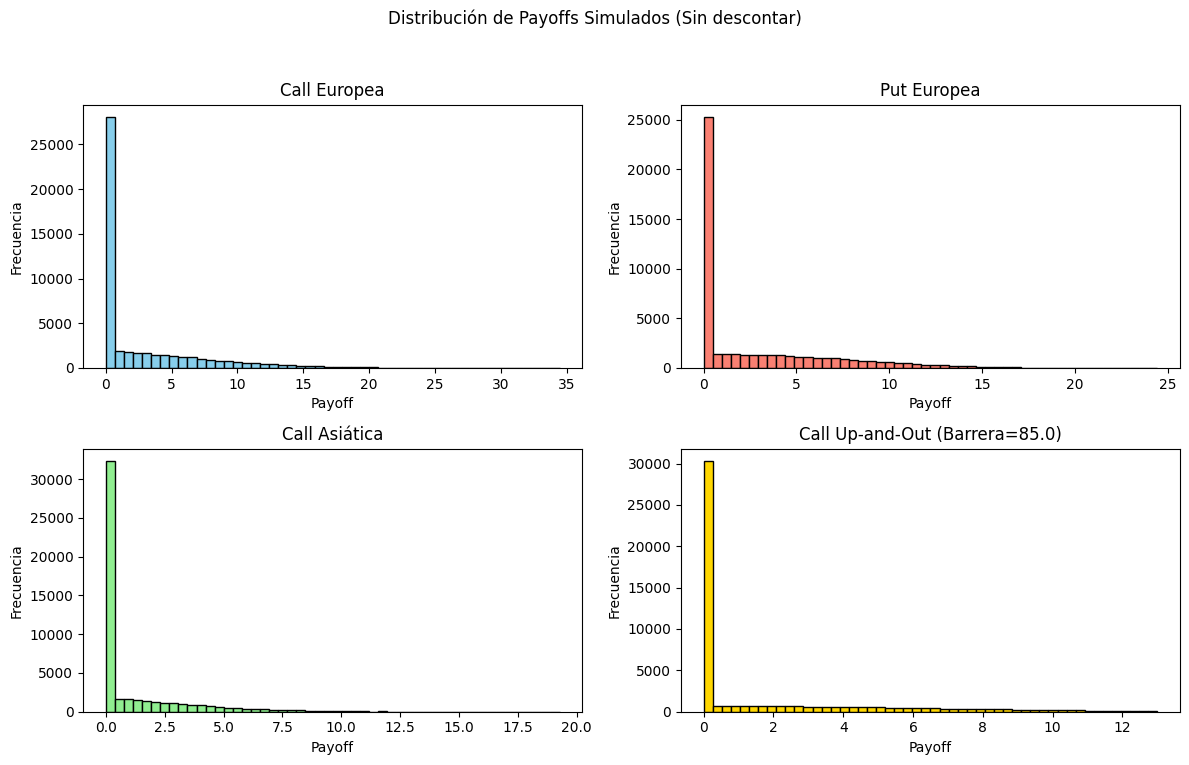

In [3]:
# ahora graficasmos 
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de Payoffs Simulados (Sin descontar)')

axs[0, 0].hist(payoff_call, bins=50, color='skyblue', edgecolor='black')
axs[0, 0].set_title('Call Europea')

axs[0, 1].hist(payoff_put, bins=50, color='salmon', edgecolor='black')
axs[0, 1].set_title('Put Europea')

axs[1, 0].hist(payoff_asiatica, bins=50, color='lightgreen', edgecolor='black')
axs[1, 0].set_title('Call Asiática')

axs[1, 1].hist(payoff_barrera, bins=50, color='gold', edgecolor='black')
axs[1, 1].set_title(f'Call Up-and-Out (Barrera={B})')

for ax in axs.flat:
    ax.set(xlabel='Payoff', ylabel='Frecuencia')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Por que la asiatica y la de barrera son mas baratas?
Basado en los graficos  se ve que estas opcions tienen menos chanses de pagar mucho. La Asiatica es mas barata por que el promedio no sube tanto como el presio final (suavisa el movimientto), entonses el "payof" es mas chiquito. La de Barrera (Up-and-Out) es barata por que si el presio sube demaciado y toca los 85.0, la opcion se muere y no te pagan nada, por eso vale menos que una call normal que no tiene limite.

Explicasion con mis propias palabras:

Call Europea: Es la base. Te paga segun el presio al final. tiene una distribusion de pagos mas ancha por que no tiene restriciones.

Put Europea: Esta es para cuando el mercado cae. Vale parecido a la call por que el estraik esta serca del presio actual.

Call Asiatica: Esta usa el promedio. Como el promedio de muchos dias es dificil que sea un numero muy loco o muy alto, el riesgo para el que la vende es menor y por eso nos cobran menos prima. En el histograma se nota que los pagos estan mas amontonados en valores bajos.

Call Up-and-Out: Es como una call normal pero con "trampa". Si la accion se emociona y sube de mas (toca la barrera), pues ya valio tu inversion. Esa probavilidadd de que se cancele ase que el presio baje a 1.80 en comparasion con los 2.75 de la normal.